In [2]:
import h5py

file_path = r"Dataset/archive/GOLD_XYZ_OSC.0001_1024.hdf5"

with h5py.File(file_path, "r") as f:
    print("Keys:")
    for key in f.keys():
        print(key)

Keys:
X
Y
Z


In [3]:
with h5py.File(file_path, "r") as f:
    for key in f.keys():
        print(key, f[key].shape)

X (2555904, 1024, 2)
Y (2555904, 24)
Z (2555904, 1)


In [4]:
import h5py
import numpy as np



with h5py.File(file_path, "r") as f:
    X = f["X"]
    Y = f["Y"]
    Z = f["Z"]

    print("X shape:", X.shape)
    print("Y shape:", Y.shape)
    print("Z shape:", Z.shape)

    print("\nFirst Y:")
    print(Y[0])

    print("\nFirst Z:")
    print(Z[0])

    print("\nX[0] shape:")
    print(X[0].shape)

    print("\nFirst 5 IQ samples:")
    print(X[0][:120])

X shape: (2555904, 1024, 2)
Y shape: (2555904, 24)
Z shape: (2555904, 1)

First Y:
[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

First Z:
[-20]

X[0] shape:
(1024, 2)

First 5 IQ samples:
[[ 4.20273952e-02  2.34763235e-01]
 [-2.72882611e-01  4.05134916e-01]
 [-2.67072618e-01  2.27498889e-01]
 [-3.14850867e-01 -1.76458597e-01]
 [ 9.63341236e-01 -1.02571023e+00]
 [ 1.87244624e-01  6.44536376e-01]
 [ 2.60705411e-01 -4.00602192e-01]
 [-1.38889417e-01  3.37220818e-01]
 [ 3.51226389e-01 -3.00818056e-01]
 [ 6.83884501e-01 -1.90601695e+00]
 [ 1.19307786e-01  7.23491237e-02]
 [-1.77766070e-01 -3.49935830e-01]
 [ 4.21254300e-02 -2.73146898e-01]
 [ 1.16819859e+00  1.35799253e+00]
 [ 1.13426137e+00  4.34401125e-01]
 [ 3.39727253e-02 -9.00930226e-01]
 [ 1.82389474e+00 -1.91117674e-01]
 [ 1.11155123e-01  3.19545120e-01]
 [ 8.38508904e-01  3.62890035e-01]
 [ 1.07418180e+00  3.98637831e-01]
 [ 3.25316995e-01 -5.00284135e-01]
 [-7.12064922e-01 -2.04506859e-01]
 [-5.76841295e-01  1.49948746e-01]
 [

In [5]:
f= h5py.File(file_path , "r")

In [6]:
X

<Closed HDF5 dataset>

In [7]:
import h5py

f = h5py.File("Dataset/archive/GOLD_XYZ_OSC.0001_1024.hdf5", "r")
x = f["X"]
print(x[0].shape)

(1024, 2)


In [8]:
y= f["Y"]
z=f["Z"]
labels = np.argmax(y , axis = 1)

In [9]:
print("Class IDs:", np.unique(labels))

Class IDs: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]


In [10]:
import json
with open(r"Dataset/archive/classes-fixed.json" , "r") as f:
    classes = json.load(f)
print(classes)

['OOK', '4ASK', '8ASK', 'BPSK', 'QPSK', '8PSK', '16PSK', '32PSK', '16APSK', '32APSK', '64APSK', '128APSK', '16QAM', '32QAM', '64QAM', '128QAM', '256QAM', 'AM-SSB-WC', 'AM-SSB-SC', 'AM-DSB-WC', 'AM-DSB-SC', 'FM', 'GMSK', 'OQPSK']


In [11]:
sample = x[319488][0]
sample

array([-0.50679684,  0.4923161 ], dtype=float32)

In [12]:
sample[:10]

array([-0.50679684,  0.4923161 ], dtype=float32)

In [13]:
label = np.argmax(y[319488])
snr = z[319488][0]

In [14]:
print("Class ID:", label)
print("Modulation:", classes[label])
print("SNR:", snr, "dB")

Class ID: 3
Modulation: BPSK
SNR: -20 dB


In [15]:
for i in [0, 4096, 8192, 106496, 106498]:
    print(i, np.argmax(y[i]), z[i][0])

0 0 -20
4096 0 -18
8192 0 -16
106496 1 -20
106498 1 -20


Text(0, 0.5, 'Amplitude')

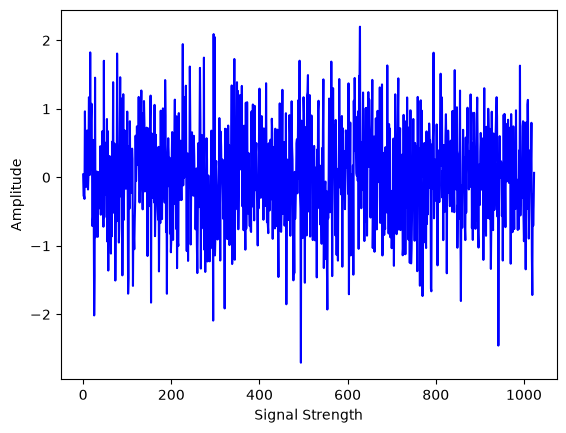

In [16]:
# Now I will plot te see how the signal works
import matplotlib.pyplot as plt
first = x[0]

plt.plot(first[: , 0] , color = "blue" )
plt.xlabel("Signal Strength")
plt.ylabel("Amplitude")

Text(0, 0.5, 'Amplitude')

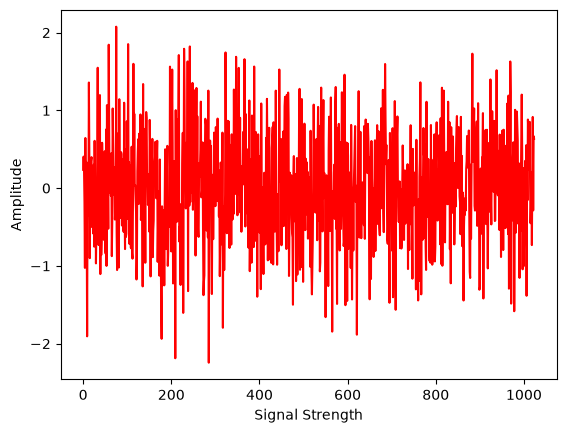

In [17]:
plt.plot( first[: ,1] , color = "red" )
plt.xlabel("Signal Strength")
plt.ylabel("Amplitude")

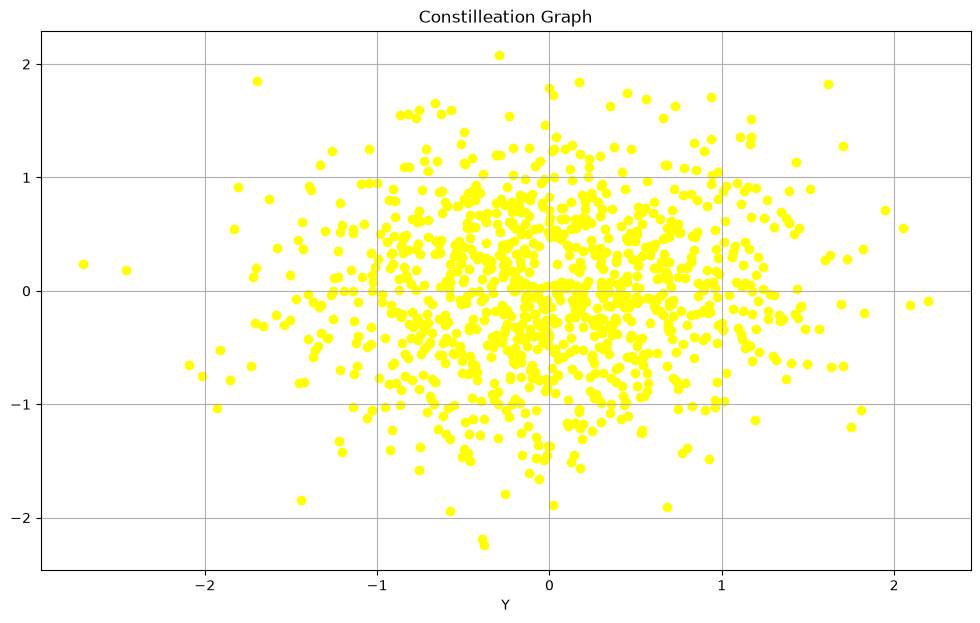

In [18]:
plt.figure(figsize=(12,7))
plt.scatter(first[: , 0] , first[: ,1] , color = "yellow" )

plt.xlabel("X")
plt.xlabel("Y")
plt.title("Constilleation Graph")

plt.grid()


In [19]:
for i in [0,100,189000,10000,969999]:
    label = np.argmax(y[i])
    snr = z[i][0]
    print(f"{i}-->{classes[label]} --> {snr}"
        
    )
    


0-->OOK --> -20
100-->OOK --> -20
189000-->4ASK --> 20
10000-->OOK --> -16
969999-->32APSK --> -16


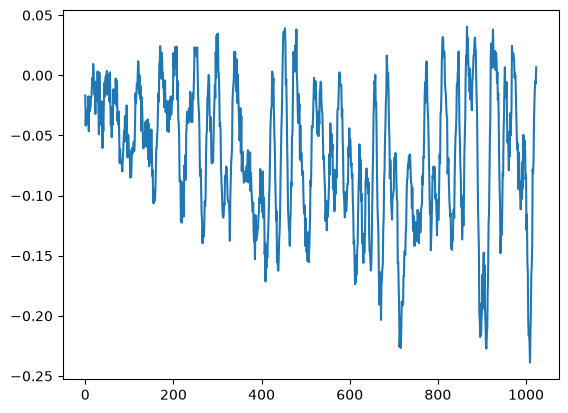

In [20]:
g = 189000
s1 = x[g]
i = s1[: , 0]
q=s1[: ,1]
plt.plot(i)

In [21]:
print(np.unique(z))

[-20 -18 -16 -14 -12 -10  -8  -6  -4  -2   0   2   4   6   8  10  12  14
  16  18  20  22  24  26  28  30]


In [22]:
for i in np.unique(z[:,0]):
    count = np.sum(z[:, 0] == i)
    print(f"{i} --> {count}")

-20 --> 98304
-18 --> 98304
-16 --> 98304
-14 --> 98304
-12 --> 98304
-10 --> 98304
-8 --> 98304
-6 --> 98304
-4 --> 98304
-2 --> 98304
0 --> 98304
2 --> 98304
4 --> 98304
6 --> 98304
8 --> 98304
10 --> 98304
12 --> 98304
14 --> 98304
16 --> 98304
18 --> 98304
20 --> 98304
22 --> 98304
24 --> 98304
26 --> 98304
28 --> 98304
30 --> 98304


In [23]:
for g in np.unique(labels):
    count = np.sum(labels == g)
    print(f"{classes[g]}--> {count}")

OOK--> 106496
4ASK--> 106496
8ASK--> 106496
BPSK--> 106496
QPSK--> 106496
8PSK--> 106496
16PSK--> 106496
32PSK--> 106496
16APSK--> 106496
32APSK--> 106496
64APSK--> 106496
128APSK--> 106496
16QAM--> 106496
32QAM--> 106496
64QAM--> 106496
128QAM--> 106496
256QAM--> 106496
AM-SSB-WC--> 106496
AM-SSB-SC--> 106496
AM-DSB-WC--> 106496
AM-DSB-SC--> 106496
FM--> 106496
GMSK--> 106496
OQPSK--> 106496


In [24]:
for i in range (0,500000 , 50000):
    label = np.argmax(y[i])
    print(label)

0
0
0
1
1
2
2
3
3
4


In [25]:
no=1096
label = np.argmax(y[no])
label
classes[label]

'OOK'

In [26]:
x[0]


array([[ 0.0420274 ,  0.23476323],
       [-0.2728826 ,  0.40513492],
       [-0.26707262,  0.22749889],
       ...,
       [-0.7055947 , -0.28693035],
       [-0.41157472,  0.66826206],
       [ 0.06487698,  0.6358149 ]], shape=(1024, 2), dtype=float32)

In [27]:
for i in range (0 , 100):
    for j in [0]:
        val = x[0][i][j]
        val1 = x[0][i][j+1]
        d = (val)**2 + (val)**2
        print(np.sqrt(d))
        
        

0.05943571
0.3859143
0.3776977
0.44526637
1.3623703
0.2648039
0.3686931
0.1964193
0.49670914
0.96715873
0.1687267
0.2513992
0.059574354
1.6520823
1.6040878
0.04804469
2.5793767
0.15719709
1.1858306
1.5191225
0.4600677
1.0070119
0.81577677
0.77156436
0.7150778
2.8514025
2.0310934
2.0572903
1.2367038
0.5590294
0.28267258
0.11899959
0.13456924
1.2297359
0.11079021
0.12262378
0.03480202
0.6383308
0.40940446
0.6425057
0.772211
0.020265548
0.2813293
0.2084861
0.9574126
0.31036985
1.0199449
2.4065344
0.8274865
0.06459589
0.030100146
0.71447784
0.3642017
0.3082762
1.2040268
1.328984
0.9536538
1.9247203
0.242059
0.75298667
0.4395975
0.20485796
0.8158514
1.5747147
0.3388151
1.2180427
0.7372664
0.3026245
1.9643414
0.35425064
0.7335391
0.69804406
0.0001913834
2.1310523
0.9066715
0.40986744
0.9062957
2.5556962
0.75518095
0.21314935
0.60826325
1.3463455
1.0311958
0.8055839
2.0663264
0.39280742
0.95077735
0.29445612
1.628492
2.0242887
0.09346916
1.7165192
0.8807573
0.11622352
0.96999675
0.08409884
0.

In [28]:
no_of_samples = 106496
samples_per_snr = 4096
sample_take = 150
X_list = []
Y_list = []
Z_list = []
for class_id in range (24):
    class_start = no_of_samples * class_id
    for snr_id in range (26):
        start = class_start + snr_id*samples_per_snr
        end = start + sample_take
        X_list.append(x[start:end])
        Y_list.append(y[start:end])
        Z_list.append(z[start:end])
X_subset = np.concatenate(X_list , axis=0)
Y_subset = np.concatenate(Y_list , axis=0)
Z_subset = np.concatenate(Z_list , axis=0)
        
        
    

In [29]:
print("X_subset:", X_subset.shape)
print("Y_subset:", Y_subset.shape)
print("Z_subset:", Z_subset.shape)

X_subset: (93600, 1024, 2)
Y_subset: (93600, 24)
Z_subset: (93600, 1)


In [30]:
Y_subset

array([[1, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 1],
       [0, 0, 0, ..., 0, 0, 1],
       [0, 0, 0, ..., 0, 0, 1]], shape=(93600, 24))

In [31]:
label1 = np.argmax(Y_subset , axis=1)


In [32]:
#  Amplitude for the extracted data 
I = X_subset[: , : ,0]
Q = X_subset[: , : ,1]
amplitude = np.sqrt(I**2+Q**2)
amplitude.shape

(93600, 1024)

In [33]:
import numpy as np
import pandas as pd

from scipy.stats import skew as scipy_skew
from scipy.stats import kurtosis as scipy_kurtosis
amp = np.sqrt(I**2 + Q**2)
phase = np.arctan2(Q, I)

# Unwrapped phase for instantaneous frequency
phase_unwrapped = np.unwrap(phase, axis=1)


# 2. Basic Amplitude Statistics
amp_mean = amp.mean(axis=1)
amp_std = amp.std(axis=1)
amp_max = amp.max(axis=1)
amp_min = amp.min(axis=1)
amp_ptp = amp_max - amp_min
amp_var = amp_std**2


# 3. Power & Ratios
power = np.mean(I**2 + Q**2, axis=1)

RMS_amp = np.sqrt(power)

crest_factor = amp_max / (RMS_amp + 1e-12)

papr = 10 * np.log10(
    (amp_max**2) / (power + 1e-12)
)


# 4. Instantaneous Frequency
inst_freq = np.diff(phase_unwrapped, axis=1)

inst_freq_mean = inst_freq.mean(axis=1)
inst_freq_std = inst_freq.std(axis=1)


# 5. Higher-Order Amplitude Moments

amp_mean_col = amp.mean(axis=1, keepdims=True)
amp_centered = amp - amp_mean_col

amp_skew = (
    np.mean(amp_centered**3, axis=1)
    / (amp_std**3 + 1e-12)
)

amp_kurtosis = (
    np.mean(amp_centered**4, axis=1)
    / (amp_std**4 + 1e-12)
    - 3
)


# 6. Scipy Skewness & Kurtosis
# Use aliases so they cannot conflict with variables named
# skew or kurtosis elsewhere in the notebook.

amp_kurt = scipy_kurtosis(amp, axis=1)

I_skew = scipy_skew(I, axis=1)
Q_skew = scipy_skew(Q, axis=1)


# 7. Feature Names
feature_names = [
    "I_mean",
    "I_std",
    "Q_mean",
    "Q_std",
    "amp_mean",
    "amp_std",
    "amp_max",
    "phase_mean",
    "phase_std",
    "power",
    "RMS_amp",
    "amp_var",
    "amp_skew",
    "amp_kurtosis",
    "amp_min",
    "amp_ptp",
    "amp_kurt",
    "I_skew",
    "Q_skew",
    "crest_factor",
    "papr",
    "inst_freq_mean",
    "inst_freq_std",
]


# 8. Stack Features
features = np.column_stack([
    I.mean(axis=1),
    I.std(axis=1),

    Q.mean(axis=1),
    Q.std(axis=1),

    amp_mean,
    amp_std,
    amp_max,

    phase.mean(axis=1),
    phase.std(axis=1),

    power,
    RMS_amp,
    amp_var,

    amp_skew,
    amp_kurtosis,

    amp_min,
    amp_ptp,
    amp_kurt,

    I_skew,
    Q_skew,

    crest_factor,
    papr,

    inst_freq_mean,
    inst_freq_std
])


# 9. Create DataFrame
df_features = pd.DataFrame(
    features,
    columns=feature_names
)




In [34]:
from sklearn.model_selection import train_test_split

X = df_features.values
y = np.asarray(label1).ravel()

x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train shape:", x_train.shape)
print("Test shape :", x_test.shape)
print("Number of classes:", len(np.unique(y)))

Train shape: (74880, 23)
Test shape : (18720, 23)
Number of classes: 24


In [35]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

xg = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=len(np.unique(y)),
    eval_metric="mlogloss",
    n_jobs=-1,
    random_state=42
)

xg.fit(x_train, y_train)

xgb_pred = xg.predict(x_test)

print("XGBoost Results")
print("-" * 40)
print("Accuracy :", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred, average="macro"))
print("Recall   :", recall_score(y_test, xgb_pred, average="macro"))
print("F1       :", f1_score(y_test, xgb_pred, average="macro"))

XGBoost Results
----------------------------------------
Accuracy : 0.41623931623931626
Precision: 0.40367970027358585
Recall   : 0.41623931623931626
F1       : 0.4086224823218855


In [36]:
from sklearn.linear_model import LogisticRegression


In [37]:
from sklearn.neighbors import KNeighborsClassifier


In [38]:
lr = LogisticRegression(max_iter=2000,
    random_state=42)





In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print("Scaled training shape:", x_train_scaled.shape)
print("Scaled testing shape :", x_test_scaled.shape)

Scaled training shape: (74880, 23)
Scaled testing shape : (18720, 23)


In [40]:
lr.fit(x_train_scaled , y_train)
lr_pred =lr.predict(x_test_scaled)
print(accuracy_score(y_test , lr_pred))
print(f1_score(y_test , lr_pred , average="macro"))
print(precision_score(y_test , lr_pred , average="macro"))
print(recall_score(y_test , lr_pred , average="macro"))

0.36527777777777776
0.34267437697675357
0.3522895035047628
0.36527777777777776


In [41]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    n_jobs=-1,
    random_state=42
)

rf.fit(x_train, y_train)

rf_pred = rf.predict(x_test)

print("Random Forest Results")
print("-" * 40)
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred, average="macro"))
print("Recall   :", recall_score(y_test, rf_pred, average="macro"))
print("F1       :", f1_score(y_test, rf_pred, average="macro"))

Random Forest Results
----------------------------------------
Accuracy : 0.4096688034188034
Precision: 0.4079813169022055
Recall   : 0.4096688034188034
F1       : 0.40777789565002726


In [42]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(
    n_neighbors=23,
    weights="uniform",
    metric="euclidean",
    n_jobs=-1
)

knn.fit(x_train_scaled, y_train)

knn_pred = knn.predict(x_test_scaled)

print("KNN Results")
print("-" * 40)
print("Accuracy :", accuracy_score(y_test, knn_pred))
print("Precision:", precision_score(y_test, knn_pred, average="macro"))
print("Recall   :", recall_score(y_test, knn_pred, average="macro"))
print("F1       :", f1_score(y_test, knn_pred, average="macro"))

KNN Results
----------------------------------------
Accuracy : 0.31490384615384615
Precision: 0.3288760504729244
Recall   : 0.31490384615384615
F1       : 0.31881222197288955


In [43]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(
    n_estimators=300,
    learning_rate=0.1,
    random_state=42
)

ada.fit(x_train, y_train)

ada_pred = ada.predict(x_test)

print("AdaBoost Results")
print("-" * 40)
print("Accuracy :", accuracy_score(y_test, ada_pred))
print("Precision:", precision_score(y_test, ada_pred, average="macro"))
print("Recall   :", recall_score(y_test, ada_pred, average="macro"))
print("F1       :", f1_score(y_test, ada_pred, average="macro"))

AdaBoost Results
----------------------------------------
Accuracy : 0.15721153846153846
Precision: 0.159550042480023
Recall   : 0.15721153846153846
F1       : 0.10761190761404182


C:\Users\mishr\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [44]:
results = pd.DataFrame({
    "Model": [
        "XGBoost",
        "KNN",
        "Logistic Regression",
        "Random Forest",
        "AdaBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, xgb_pred),
        accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, ada_pred)
    ],
    "Precision": [
        precision_score(y_test, xgb_pred, average="macro"),
        precision_score(y_test, knn_pred, average="macro"),
        precision_score(y_test, lr_pred, average="macro"),
        precision_score(y_test, rf_pred, average="macro"),
        precision_score(y_test, ada_pred, average="macro")
    ],
    "Recall": [
        recall_score(y_test, xgb_pred, average="macro"),
        recall_score(y_test, knn_pred, average="macro"),
        recall_score(y_test, lr_pred, average="macro"),
        recall_score(y_test, rf_pred, average="macro"),
        recall_score(y_test, ada_pred, average="macro")
    ],
    "F1": [
        f1_score(y_test, xgb_pred, average="macro"),
        f1_score(y_test, knn_pred, average="macro"),
        f1_score(y_test, lr_pred, average="macro"),
        f1_score(y_test, rf_pred, average="macro"),
        f1_score(y_test, ada_pred, average="macro")
    ]
})

results

C:\Users\mishr\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Model,Accuracy,Precision,Recall,F1
0,XGBoost,0.416239,0.403680,0.416239,0.408622
1,KNN,0.314904,0.328876,0.314904,0.318812
2,Logistic Regression,0.365278,0.352290,0.365278,0.342674
3,Random Forest,0.409669,0.407981,0.409669,0.407778
4,AdaBoost,0.157212,0.159550,0.157212,0.107612


In [45]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import numpy as np

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

PyTorch version: 2.11.0+cu128
CUDA available: True
Using device: cuda


In [46]:
# Original IQ data
X_raw = X_subset.astype(np.float32)
y_raw = np.asarray(label1).astype(np.int64)

print("Raw IQ shape:", X_raw.shape)
print("Labels shape:", y_raw.shape)

Raw IQ shape: (93600, 1024, 2)
Labels shape: (93600,)


## Phase 2 — Self-Supervised Contrastive Pretraining + Open-Set Detection

**Scope for this abstract:** RadioML 2018.01A only. Near-neighbor open-set split — `64QAM` held out entirely as "unknown," the rest of the QAM family (16/32/128/256QAM) plus all other classes stay "known." No labels are used during pretraining, only during the linear probe and for building known-class centroids.

Cross-domain (DroneRF/CardRF) is explicitly out of scope here — future work only.


In [47]:
# --- Load known/unknown split directly from the HDF5 file (fixes the X_raw/y_raw
#     length mismatch from cell 57 -- we no longer rely on the stale `label1` var) ---

import json
import numpy as np
import h5py

with open(r"Dataset/archive/classes-fixed.json", "r") as f:
    CLASS_NAMES = json.load(f)   # list of 24 modulation names, index = class_id

NUM_CLASSES = len(CLASS_NAMES)
SAMPLES_PER_CLASS = 106496   # fixed layout of RadioML 2018.01A
SNRS_PER_CLASS = 26
SAMPLES_PER_SNR = 4096

# --- near-neighbor open-set split ---
UNKNOWN_CLASS_NAMES = ["64QAM"]          # held out entirely -- never seen in pretraining or probing
KNOWN_CLASS_NAMES = [c for c in CLASS_NAMES if c not in UNKNOWN_CLASS_NAMES]

UNKNOWN_IDS = [CLASS_NAMES.index(c) for c in UNKNOWN_CLASS_NAMES]
KNOWN_IDS = [CLASS_NAMES.index(c) for c in KNOWN_CLASS_NAMES]

print(f"Known classes ({len(KNOWN_IDS)}):", KNOWN_CLASS_NAMES)
print(f"Unknown (held-out) classes ({len(UNKNOWN_IDS)}):", UNKNOWN_CLASS_NAMES)

# how many samples to pull per (class, SNR) bin -- bump this up later once the
# pipeline runs end to end; 300/bin keeps the first pass fast
SAMPLES_PER_BIN = 500  # bumped up for a richer encoder

def load_class_block(f, class_id, samples_per_bin=SAMPLES_PER_BIN):
    """Load samples_per_bin examples from every SNR bin for one class_id.
    Returns (X: [n,1024,2] float32, snr: [n] int, label: [n] int)."""
    X_list, snr_list = [], []
    class_start = SAMPLES_PER_CLASS * class_id
    for snr_id in range(SNRS_PER_CLASS):
        start = class_start + snr_id * SAMPLES_PER_SNR
        end = start + samples_per_bin
        X_list.append(f["X"][start:end])
        snr_list.append(f["Z"][start:end, 0])
    X = np.concatenate(X_list, axis=0).astype(np.float32)
    snr = np.concatenate(snr_list, axis=0).astype(np.int64)
    label = np.full(len(X), class_id, dtype=np.int64)
    return X, snr, label

with h5py.File(file_path, "r") as f:
    known_X, known_snr, known_y = [], [], []
    for cid in KNOWN_IDS:
        Xc, snrc, yc = load_class_block(f, cid)
        known_X.append(Xc); known_snr.append(snrc); known_y.append(yc)
    known_X = np.concatenate(known_X, axis=0)
    known_snr = np.concatenate(known_snr, axis=0)
    known_y = np.concatenate(known_y, axis=0)

    unknown_X, unknown_snr, unknown_y = [], [], []
    for cid in UNKNOWN_IDS:
        Xc, snrc, yc = load_class_block(f, cid)
        unknown_X.append(Xc); unknown_snr.append(snrc); unknown_y.append(yc)
    unknown_X = np.concatenate(unknown_X, axis=0)
    unknown_snr = np.concatenate(unknown_snr, axis=0)
    unknown_y = np.concatenate(unknown_y, axis=0)

print("Known X:", known_X.shape, "| Unknown X:", unknown_X.shape)


Known classes (23): ['OOK', '4ASK', '8ASK', 'BPSK', 'QPSK', '8PSK', '16PSK', '32PSK', '16APSK', '32APSK', '64APSK', '128APSK', '16QAM', '32QAM', '128QAM', '256QAM', 'AM-SSB-WC', 'AM-SSB-SC', 'AM-DSB-WC', 'AM-DSB-SC', 'FM', 'GMSK', 'OQPSK']
Unknown (held-out) classes (1): ['64QAM']
Known X: (299000, 1024, 2) | Unknown X: (13000, 1024, 2)


In [48]:
# --- train/val/test split for known classes (stratified by class), plus a held-out
#     test split for the unknown class. Unknown data is NEVER used in pretraining
#     or in the linear probe -- only at open-set evaluation time. ---

from sklearn.model_selection import train_test_split

SEED = 42

k_train_idx, k_temp_idx = train_test_split(
    np.arange(len(known_X)), test_size=0.30, random_state=SEED, stratify=known_y
)
k_val_idx, k_test_idx = train_test_split(
    k_temp_idx, test_size=0.5, random_state=SEED, stratify=known_y[k_temp_idx]
)

X_train, y_train, snr_train = known_X[k_train_idx], known_y[k_train_idx], known_snr[k_train_idx]
X_val,   y_val,   snr_val   = known_X[k_val_idx],   known_y[k_val_idx],   known_snr[k_val_idx]
X_test,  y_test,  snr_test  = known_X[k_test_idx],  known_y[k_test_idx],  known_snr[k_test_idx]

# unknown data only used at test time
X_unk, y_unk, snr_unk = unknown_X, unknown_y, unknown_snr

print("Train:", X_train.shape, "Val:", X_val.shape, "Test (known):", X_test.shape, "Test (unknown):", X_unk.shape)


Train: (209300, 1024, 2) Val: (44850, 1024, 2) Test (known): (44850, 1024, 2) Test (unknown): (13000, 1024, 2)


In [49]:
# --- import dataset/model/augmentation code from iq_utils.py ---
# (moved out of notebook cells into a real .py file so DataLoader(num_workers>0)
#  works on Windows: worker processes need to `import` this cleanly, not
#  re-execute notebook cell state)
from iq_utils import (
    time_shift, phase_rotation, noise_injection, channel_distortion, augment,
    ContrastiveIQDataset, LabeledIQDataset, IQEncoder, ProjectionHead, nt_xent_loss
)
from torch.utils.data import DataLoader


In [50]:
# --- DEBUG VERSION - Find where it's hanging ---

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

print("="*50)
print("DEBUG: Starting training...")
print("="*50)

# Check device
print(f"1. Device: {device}")
print(f"2. CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"3. GPU: {torch.cuda.get_device_name(0)}")
    print(f"4. VRAM: {torch.cuda.get_device_properties(0).total_memory/1024**3:.1f} GB")

# Check data
print(f"5. X_train shape: {X_train.shape}")
print(f"6. Dataset size: {len(train_contrastive_ds)}")

# Check loader
print(f"7. Loader batches: {len(train_contrastive_loader)}")

# TEST: Try loading one batch
print("\n8. Testing data loader (this should be instant)...")
try:
    test_batch = next(iter(train_contrastive_loader))
    print(f"   ✓ Batch loaded! Shape: {test_batch[0].shape}")
    print(f"   ✓ Batch on CPU, moving to GPU now...")
    x1, x2 = test_batch[0].to(device), test_batch[1].to(device)
    print(f"   ✓ Moved to {device}")
except Exception as e:
    print(f"   ✗ ERROR: {e}")
    raise

# Test model forward pass
print("\n9. Testing model forward pass...")
try:
    with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
        z1 = proj_head(encoder(x1))
        z2 = proj_head(encoder(x2))
        loss = nt_xent_loss(z1, z2)
    print(f"   ✓ Forward pass successful! Loss: {loss.item():.4f}")
except Exception as e:
    print(f"   ✗ ERROR: {e}")
    raise

# Test backward pass
print("\n10. Testing backward pass...")
try:
    optimizer.zero_grad()
    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()
    print(f"   ✓ Backward pass successful!")
except Exception as e:
    print(f"   ✗ ERROR: {e}")
    raise

print("\n" + "="*50)
print("✅ ALL TESTS PASSED! Training should work now.")
print("="*50)
print("\nStarting actual training...")

# NOW RUN THE ACTUAL TRAINING WITH PROGRESS BAR
from tqdm import tqdm

pretrain_losses = []
best_loss = float("inf")
patience, patience_counter = 8, 0

for epoch in range(EPOCHS):
    encoder.train()
    proj_head.train()
    running_loss = 0.0
    
    # ADD TQDM PROGRESS BAR
    pbar = tqdm(train_contrastive_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    
    for batch_idx, (x1, x2) in enumerate(pbar):
        x1, x2 = x1.to(device, non_blocking=True), x2.to(device, non_blocking=True)

        optimizer.zero_grad()
        
        with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
            z1 = proj_head(encoder(x1))
            z2 = proj_head(encoder(x2))
            loss = nt_xent_loss(z1, z2)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item()
        
        # Update progress bar
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    scheduler.step()
    avg_loss = running_loss / len(train_contrastive_loader)
    pretrain_losses.append(avg_loss)
    
    if epoch % 5 == 0 or epoch == EPOCHS - 1:
        print(f"Epoch {epoch+1}/{EPOCHS} | contrastive loss: {avg_loss:.4f}")

    # Early stopping
    if avg_loss < best_loss - 1e-4:
        best_loss = avg_loss
        patience_counter = 0
        best_encoder_state = {k: v.cpu().clone() for k, v in encoder.state_dict().items()}
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1} (loss plateaued)")
            break

# Restore best checkpoint
if best_encoder_state is not None:
    encoder.load_state_dict(best_encoder_state)
    print("Loaded best encoder state from early stopping")

plt.plot(pretrain_losses)
plt.xlabel("Epoch")
plt.ylabel("NT-Xent loss")
plt.title("SimCLR Pretraining Loss")
plt.grid(alpha=0.3)
plt.show()

DEBUG: Starting training...
1. Device: cuda
2. CUDA available: True
3. GPU: NVIDIA GeForce RTX 4050 Laptop GPU
4. VRAM: 6.0 GB
5. X_train shape: (209300, 1024, 2)


NameError: name 'train_contrastive_ds' is not defined

Original data size: 209300
Subset data size: 90000
Batches per epoch: 300
Estimated time per epoch: ~10-15 seconds

Starting training...


Epoch 1/40: 100%|██████████| 300/300 [01:32<00:00,  3.23it/s, loss=4.8196]


Epoch 1/40 | contrastive loss: 5.0452


Epoch 2/40: 100%|██████████| 300/300 [01:13<00:00,  4.08it/s, loss=4.7663]


Epoch 2/40 | contrastive loss: 4.7948


...

Epoch 38/40 | contrastive loss: 4.5867


Epoch 39/40: 100%|██████████| 300/300 [01:07<00:00,  4.42it/s, loss=4.6086]


Epoch 39/40 | contrastive loss: 4.5862


Epoch 40/40: 100%|██████████| 300/300 [01:08<00:00,  4.40it/s, loss=4.5722]


Epoch 40/40 | contrastive loss: 4.5859
Loaded best encoder state from early stopping

Training complete! Plotting loss...


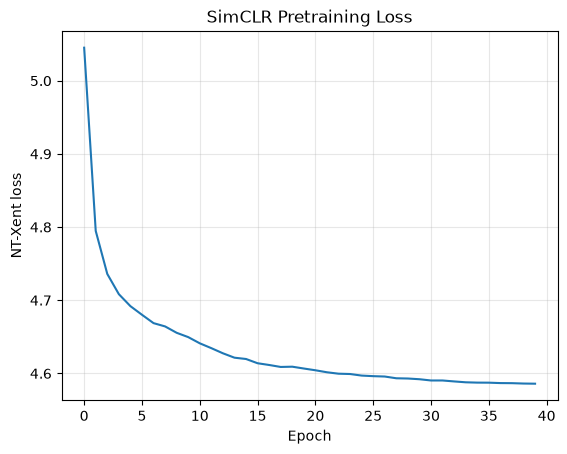

In [54]:
# --- Contrastive pretraining on KNOWN classes only, no labels used ---
# Uses mixed precision (AMP): faster and lighter on your GPU/laptop for the same work.

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

# Install tqdm if not present
try:
    from tqdm import tqdm
except ImportError:
    print("Installing tqdm...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'tqdm', '-q'])
    from tqdm import tqdm

# FIXED: nt_xent_loss with float16 compatibility
def nt_xent_loss(z1, z2, temperature=0.5):
    """Normalized Temperature-scaled Cross Entropy Loss - Fixed for AMP"""
    B = z1.shape[0]
    z = torch.cat([z1, z2], dim=0)  # (2*batch_size, proj_dim)
    sim = torch.matmul(z, z.T) / temperature
    mask = torch.eye(2 * B, dtype=torch.bool, device=z.device)
    # FIXED: -1e4 instead of -1e9 (float16 can handle -1e4)
    sim = sim.masked_fill(mask, -1e4)
    targets = torch.cat([torch.arange(B, 2 * B), torch.arange(0, B)]).to(z.device)
    return F.cross_entropy(sim, targets)

# ============= REDUCED DATA SIZE FOR LAPTOP =============
SUBSET_SIZE = 90000  # Use 20k samples instead of 209k
print(f"Original data size: {len(X_train)}")
np.random.seed(42)
indices = np.random.choice(len(X_train), SUBSET_SIZE, replace=False)
X_train_subset = X_train[indices]
y_train_subset = y_train[indices]
snr_train_subset = snr_train[indices]
print(f"Subset data size: {len(X_train_subset)}")

BATCH_SIZE = 300  # Reduced from 512 for faster iteration
EMBED_DIM = 128
PROJ_DIM = 64
EPOCHS = 40  # Reduced from 50
LR = 3e-4

train_contrastive_ds = ContrastiveIQDataset(X_train_subset)
train_contrastive_loader = DataLoader(train_contrastive_ds, batch_size=BATCH_SIZE,
                                       shuffle=True, num_workers=0, drop_last=True,
                                       pin_memory=True)

print(f"Batches per epoch: {len(train_contrastive_loader)}")
print(f"Estimated time per epoch: ~10-15 seconds")
print("="*50)

encoder = IQEncoder(embed_dim=EMBED_DIM).to(device)
proj_head = ProjectionHead(embed_dim=EMBED_DIM, proj_dim=PROJ_DIM).to(device)

optimizer = torch.optim.Adam(list(encoder.parameters()) + list(proj_head.parameters()), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# FIXED: New AMP syntax (no more warnings)
scaler = torch.amp.GradScaler('cuda', enabled=torch.cuda.is_available())

pretrain_losses = []
best_loss = float("inf")
patience, patience_counter = 8, 0   # early stop if loss stops improving

print("\nStarting training...")
print("="*50)

for epoch in range(EPOCHS):
    encoder.train()
    proj_head.train()
    running_loss = 0.0
    
    # ADDED: Progress bar with tqdm
    pbar = tqdm(train_contrastive_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    
    for x1, x2 in pbar:
        x1, x2 = x1.to(device, non_blocking=True), x2.to(device, non_blocking=True)

        optimizer.zero_grad()
        
        # FIXED: New AMP syntax
        with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
            z1 = proj_head(encoder(x1))
            z2 = proj_head(encoder(x2))
            loss = nt_xent_loss(z1, z2)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item()
        
        # Update progress bar with current loss
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    scheduler.step()
    avg_loss = running_loss / len(train_contrastive_loader)
    pretrain_losses.append(avg_loss)
    
    # Print every epoch (not just every 5th)
    print(f"Epoch {epoch+1}/{EPOCHS} | contrastive loss: {avg_loss:.4f}")

    # Early stopping - save best model
    if avg_loss < best_loss - 1e-4:
        best_loss = avg_loss
        patience_counter = 0
        best_encoder_state = {k: v.cpu().clone() for k, v in encoder.state_dict().items()}
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1} (loss plateaued)")
            break

# Restore best checkpoint
if best_encoder_state is not None:
    encoder.load_state_dict(best_encoder_state)
    print("Loaded best encoder state from early stopping")

print("\nTraining complete! Plotting loss...")
plt.plot(pretrain_losses)
plt.xlabel("Epoch")
plt.ylabel("NT-Xent loss")
plt.title("SimCLR Pretraining Loss")
plt.grid(alpha=0.3)
plt.show()

Extracting embeddings...

Training linear probe...
C=   0.0, Val accuracy: 0.3454
C=   0.0, Val accuracy: 0.3684
C=   0.1, Val accuracy: 0.3910
C=   1.0, Val accuracy: 0.4053
C=  10.0, Val accuracy: 0.4124
C= 100.0, Val accuracy: 0.4214

--- Final Results ---
Linear probe closed-set accuracy: 0.4188
Validation accuracy: 0.4214
Random baseline: 0.0435

--- Per-class accuracy ---
Class  0: 0.7221
Class  1: 0.5759
Class  2: 0.6000
Class  3: 0.7082
Class  4: 0.6426
Class  5: 0.3092
Class  6: 0.2082
Class  7: 0.1964
Class  8: 0.4846
Class  9: 0.5292
Class 10: 0.0733
Class 11: 0.1297
Class 12: 0.1062
Class 13: 0.0831
Class 15: 0.0369
Class 16: 0.1031
Class 17: 0.4051
Class 18: 0.5651
Class 19: 0.5021
Class 20: 0.4805
Class 21: 0.8000
Class 22: 0.7123
Class 23: 0.6590


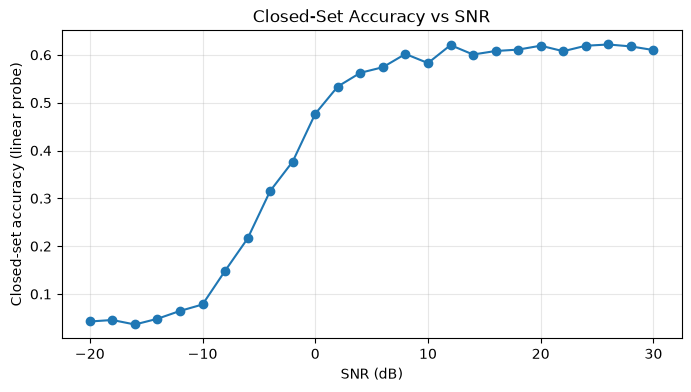

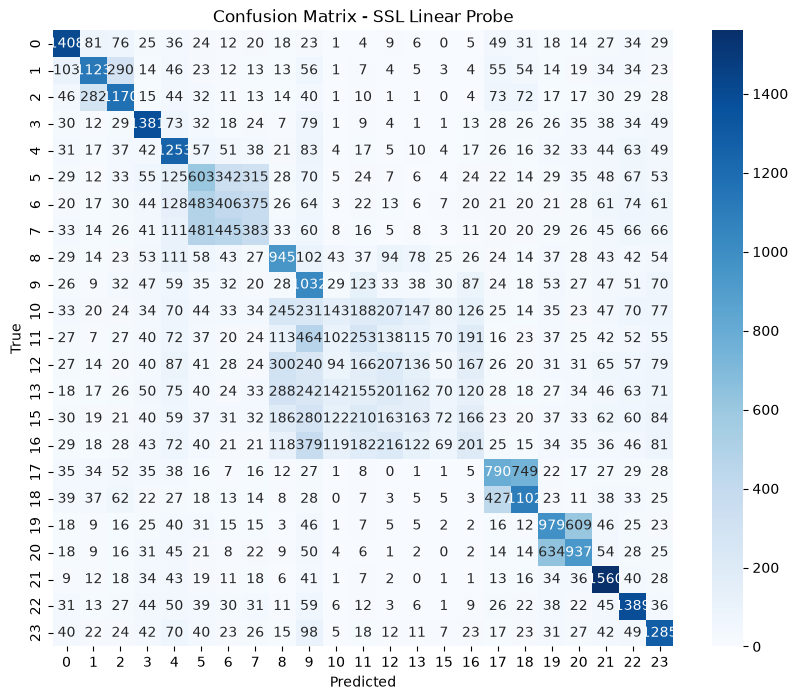

In [55]:
# --- Freeze encoder, extract embeddings, linear probe for closed-set accuracy ---

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.dummy import DummyClassifier
import seaborn as sns

@torch.no_grad()
def get_embeddings(encoder, X, batch_size=512):
    encoder.eval()
    X_t = torch.from_numpy(X).float().permute(0, 2, 1)
    embs = []
    for i in range(0, len(X_t), batch_size):
        batch = X_t[i:i+batch_size].to(device)
        embs.append(encoder(batch).cpu().numpy())
    return np.concatenate(embs, axis=0)

# Extract embeddings
print("Extracting embeddings...")
emb_train = get_embeddings(encoder, X_train)
emb_val = get_embeddings(encoder, X_val)
emb_test = get_embeddings(encoder, X_test)
emb_unk = get_embeddings(encoder, X_unk) 

# Train linear probe with validation
print("\nTraining linear probe...")
best_acc = 0
best_probe = None
for C in [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]:
    probe = LogisticRegression(max_iter=2000, random_state=SEED, C=C)
    probe.fit(emb_train, y_train)
    val_acc = accuracy_score(y_val, probe.predict(emb_val))
    print(f"C={C:6.1f}, Val accuracy: {val_acc:.4f}")
    if val_acc > best_acc:
        best_acc = val_acc
        best_probe = probe

probe = best_probe
probe_pred = probe.predict(emb_test)
test_acc = accuracy_score(y_test, probe_pred)

print(f"\n--- Final Results ---")
print(f"Linear probe closed-set accuracy: {test_acc:.4f}")
print(f"Validation accuracy: {best_acc:.4f}")

# Compare with random baseline
dummy = DummyClassifier(strategy='most_frequent').fit(emb_train, y_train)
print(f"Random baseline: {accuracy_score(y_test, dummy.predict(emb_test)):.4f}")

# Per-class accuracy
print("\n--- Per-class accuracy ---")
for class_id in np.unique(y_test):
    mask = y_test == class_id
    acc = accuracy_score(y_test[mask], probe_pred[mask])
    print(f"Class {class_id:2d}: {acc:.4f}")

# SNR-stratified closed-set accuracy
snr_bins = sorted(np.unique(snr_test))
closed_set_by_snr = []
for s in snr_bins:
    mask = snr_test == s
    acc = accuracy_score(y_test[mask], probe_pred[mask]) if mask.sum() > 0 else np.nan
    closed_set_by_snr.append(acc)

plt.figure(figsize=(8, 4))
plt.plot(snr_bins, closed_set_by_snr, marker="o")
plt.xlabel("SNR (dB)")
plt.ylabel("Closed-set accuracy (linear probe)")
plt.title("Closed-Set Accuracy vs SNR")
plt.grid(alpha=0.3)
plt.show()

# Confusion matrix
cm = confusion_matrix(y_test, probe_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=np.unique(y_test), 
            yticklabels=np.unique(y_test))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - SSL Linear Probe')
plt.show()

In [57]:
# --- Open-set scoring: Mahalanobis distance ---
from sklearn.covariance import LedoitWolf
from sklearn.metrics import roc_auc_score
import numpy as np

def mahalanobis_score(embs, class_means, precision):
    """Min Mahalanobis distance to any known-class mean.
    Returns: LOWER score = MORE known (original distance)
    """
    dists = []
    for c, mu in class_means.items():
        diff = embs - mu
        d = np.einsum("ij,jk,ik->i", diff, precision, diff)
        dists.append(d)
    min_dists = np.stack(dists, axis=1).min(axis=1)
    # NO INVERSION: Keep lower = more known
    return min_dists  # <--- REMOVED the negation

# Compute class means
class_means = {c: emb_train[y_train == c].mean(axis=0) for c in KNOWN_IDS}

# Compute precision matrix
centered = np.concatenate([emb_train[y_train == c] - class_means[c] for c in KNOWN_IDS], axis=0)
cov_estimator = LedoitWolf().fit(centered)
precision = cov_estimator.precision_

# Get scores (LOWER = more known)
score_known = mahalanobis_score(emb_test, class_means, precision)
score_unk = mahalanobis_score(emb_unk, class_means, precision)

# Create labels: 0 = known, 1 = unknown (OOD)
ood_labels = np.concatenate([np.zeros(len(score_known)), np.ones(len(score_unk))])
scores = np.concatenate([score_known, score_unk])

# Calculate AUROC: Since lower scores = known, we negate scores for ROC
# (ROC expects higher scores = positive class, which is "known" here)
auroc = roc_auc_score(ood_labels, -scores)  # Negate so known samples get higher scores

# Calculate FPR95: At 95% TPR, what's the FPR?
# Threshold at 5th percentile of known scores (LOWER = more known)
thr = np.percentile(score_known, 95)  # 95th percentile (high threshold)
# OOD samples with score <= threshold are misclassified as known
fpr95 = (score_unk <= thr).mean()

print(f"\n--- Open-Set Detection Results ---")
print(f"Mahalanobis distance AUROC: {auroc:.4f} | FPR95: {fpr95:.4f}")


--- Open-Set Detection Results ---
Mahalanobis distance AUROC: 0.6586 | FPR95: 1.0000


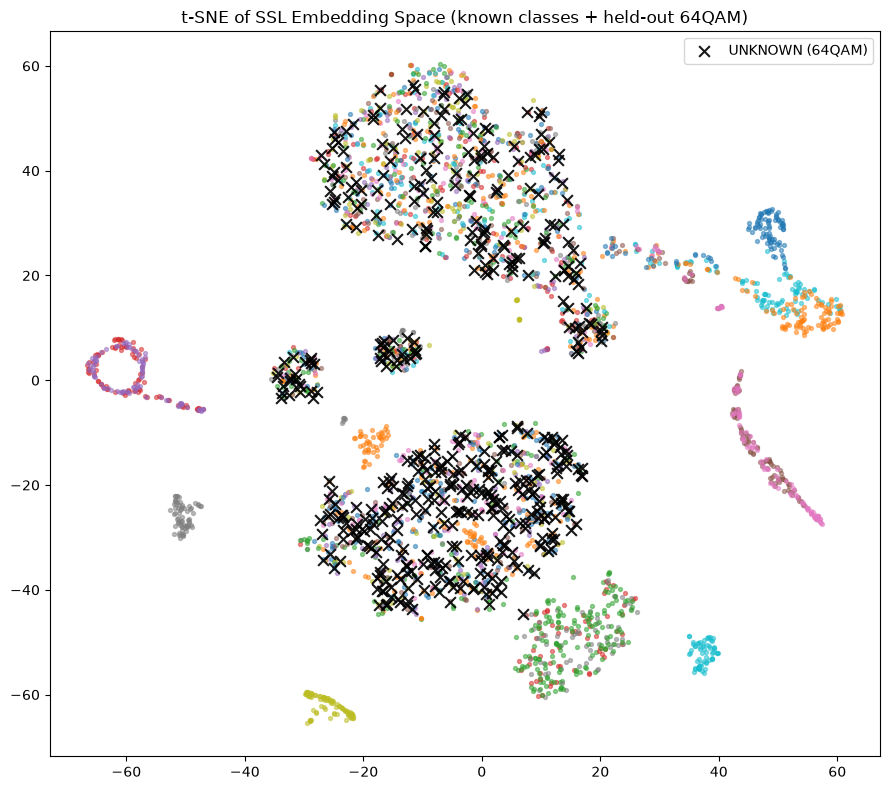

In [58]:
# --- t-SNE of SSL embedding space: known classes + the held-out unknown class ---
# (Use a subsample for speed -- t-SNE is O(n^2)-ish.)

from sklearn.manifold import TSNE

N_TSNE = 3000
rng = np.random.default_rng(SEED)

idx_known = rng.choice(len(emb_test), size=min(N_TSNE, len(emb_test)), replace=False)
idx_unk = rng.choice(len(emb_unk), size=min(500, len(emb_unk)), replace=False)

tsne_input = np.concatenate([emb_test[idx_known], emb_unk[idx_unk]], axis=0)
tsne_labels = np.concatenate([
    [CLASS_NAMES[c] for c in y_test[idx_known]],
    ["UNKNOWN (64QAM)"] * len(idx_unk)
])

tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, init="pca")
tsne_out = tsne.fit_transform(tsne_input)

plt.figure(figsize=(9, 8))
for lbl in np.unique(tsne_labels):
    mask = tsne_labels == lbl
    is_unknown = lbl.startswith("UNKNOWN")
    plt.scatter(tsne_out[mask, 0], tsne_out[mask, 1],
                s=60 if is_unknown else 8,
                marker="x" if is_unknown else "o",
                c="black" if is_unknown else None,
                alpha=0.9 if is_unknown else 0.5,
                label=lbl if is_unknown else None)
plt.title("t-SNE of SSL Embedding Space (known classes + held-out 64QAM)")
plt.legend()
plt.tight_layout()
plt.show()


In [60]:
# Search your notebook's variables for anything that looks like the class/label list
for name, val in list(globals().items()):
    if isinstance(val, (list, np.ndarray)) and 0 < len(val) <= 30:
        try:
            if any(isinstance(x, str) for x in val):
                print(name, "->", val)
        except:
            pass

classes -> ['OOK', '4ASK', '8ASK', 'BPSK', 'QPSK', '8PSK', '16PSK', '32PSK', '16APSK', '32APSK', '64APSK', '128APSK', '16QAM', '32QAM', '64QAM', '128QAM', '256QAM', 'AM-SSB-WC', 'AM-SSB-SC', 'AM-DSB-WC', 'AM-DSB-SC', 'FM', 'GMSK', 'OQPSK']
feature_names -> ['I_mean', 'I_std', 'Q_mean', 'Q_std', 'amp_mean', 'amp_std', 'amp_max', 'phase_mean', 'phase_std', 'power', 'RMS_amp', 'amp_var', 'amp_skew', 'amp_kurtosis', 'amp_min', 'amp_ptp', 'amp_kurt', 'I_skew', 'Q_skew', 'crest_factor', 'papr', 'inst_freq_mean', 'inst_freq_std']
CLASS_NAMES -> ['OOK', '4ASK', '8ASK', 'BPSK', 'QPSK', '8PSK', '16PSK', '32PSK', '16APSK', '32APSK', '64APSK', '128APSK', '16QAM', '32QAM', '64QAM', '128QAM', '256QAM', 'AM-SSB-WC', 'AM-SSB-SC', 'AM-DSB-WC', 'AM-DSB-SC', 'FM', 'GMSK', 'OQPSK']
UNKNOWN_CLASS_NAMES -> ['64QAM']
KNOWN_CLASS_NAMES -> ['OOK', '4ASK', '8ASK', 'BPSK', 'QPSK', '8PSK', '16PSK', '32PSK', '16APSK', '32APSK', '64APSK', '128APSK', '16QAM', '32QAM', '128QAM', '256QAM', 'AM-SSB-WC', 'AM-SSB-SC', 'A